# Fase 3b · Series mensuales

EDA de `data/intermediate/series_mensuales.parquet`: tabla larga con la cuota de cada tópico, el tono simple y ponderado, la tasa de outliers y el volumen mensual. Los meses sin sesiones se conservan con `has_session: false` y quedan fuera del modelado (D-28). La lógica reproducible vive en `src/analysis/temporal.py`; las figuras finales, en `src/visualization/charts.py`.

In [1]:
# Localiza la raíz del repositorio para poder importar `src`
# tanto desde VS Code (cwd=notebooks) como con nbclient (cwd=raíz).
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "pyproject.toml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

In [2]:
import pandas as pd
from src.utils.config import PROJECT_ROOT

series = pd.read_parquet(PROJECT_ROOT / "data/intermediate/series_mensuales.parquet")
print(series.shape)
active = series.loc[series["has_session"]].groupby("month")["n_interventions"].first()
print("meses con sesión:", active.size, "| meses totales:", series["month"].nunique())
series.groupby("series_type")["series_id"].nunique()

(6076, 6)
meses con sesión: 82 | meses totales: 98


series_type
outliers          1
tone              1
tone_weighted     1
topic            58
volume            1
Name: series_id, dtype: int64

In [3]:
tone = series.loc[series["series_type"] == "tone"].set_index("month")["value"]
tone_weighted = series.loc[series["series_type"] == "tone_weighted"].set_index("month")["value"]
print(tone.describe().round(3))
print(tone_weighted.describe().round(3))

count    82.000
mean      1.875
std       0.270
min       1.258
25%       1.720
50%       1.860
75%       1.978
max       2.999
Name: value, dtype: float64
count    82.000
mean      1.884
std       0.262
min       1.365
25%       1.753
50%       1.847
75%       1.971
max       2.974
Name: value, dtype: float64


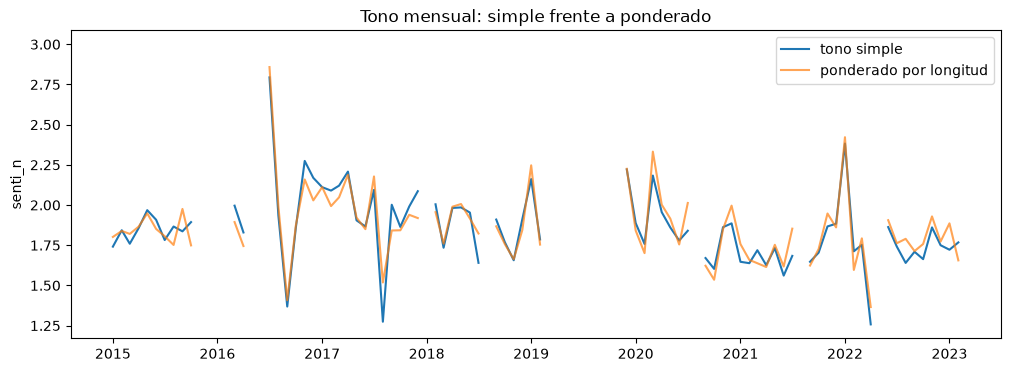

: 

In [ ]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(figsize=(12, 4))
axes.plot(tone.index, tone.to_numpy(), label="tono simple")
axes.plot(tone_weighted.index, tone_weighted.to_numpy(), alpha=0.7, label="ponderado por longitud")
axes.set_ylabel("senti_n")
axes.set_title("Tono mensual: simple frente a ponderado")
axes.legend()
plt.show()